## Plotting notebook

In [3]:
pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 124.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd

## Validating M/D/1 Queue Theory 

In [16]:
df = pd.read_csv('result_test.csv', usecols = ["Request Rate","Inferences/Second", "Server Queue"])
print(df)

   Request Rate  Inferences/Second  Server Queue
0            66            63.4895          2161
1            99            96.7787          3181
2           132           128.9970          3335
3           165           160.4810          3555
4           198           194.6730          4408
5           231           229.9470          3604
6           264           261.0010         10195
7           297           297.4990         12746


In [5]:
pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 111.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [6]:
import matplotlib.pyplot as plt

In [65]:
df.columns= df.columns.str.strip()
max_serv_rate = 330
df["Rho Values"] = df['Request Rate']/max_serv_rate

In [66]:
#theory queue time
theory_q_time = []
for rho in df["Rho Values"]:
    val = (10**6)*rho/(2*max_serv_rate*(1-rho))
    theory_q_time.append(val)
df['Theory Queue Time']=theory_q_time

In [67]:
#for value in rho_values:
#    print(value)
print(df)

   Request Rate  Inferences/Second  Server Queue  Rho Values  \
0            66            63.4895          2161         0.2   
1            99            96.7787          3181         0.3   
2           132           128.9970          3335         0.4   
3           165           160.4810          3555         0.5   
4           198           194.6730          4408         0.6   
5           231           229.9470          3604         0.7   
6           264           261.0010         10195         0.8   
7           297           297.4990         12746         0.9   

   Theory Queue Time  
0         378.787879  
1         649.350649  
2        1010.101010  
3        1515.151515  
4        2272.727273  
5        3535.353535  
6        6060.606061  
7       13636.363636  


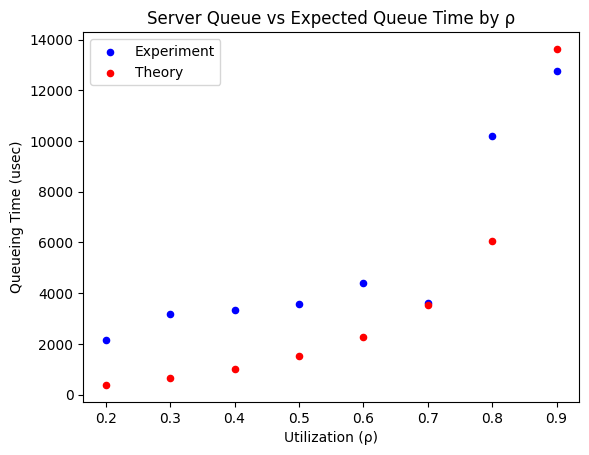

In [70]:
# Create the plot
fig, ax = plt.subplots()

df.plot.scatter(x='Rho Values', y='Server Queue', color='blue', label='Experiment', ax=ax)
df.plot.scatter(x='Rho Values', y='Theory Queue Time', color='red', label='Theory', ax=ax)
# Add legend
ax.set_title('Server Queue vs Expected Queue Time by ρ')
ax.set_xlabel('Utilization (ρ)')
ax.set_ylabel('Queueing Time (usec)')
ax.legend()
plt.legend()

# Show the plot
plt.show()

## Validating Batches as Bulk Queues

In [72]:
import glob

Combining all batch*.csv files to one file: batch_results.csv

In [87]:

all_batches = []

for filepath in sorted(glob.glob("batch*.csv")):
    batch_name = filepath.replace(".csv", "") 
    batch_name = batch_name.replace("batch", "")
    df = pd.read_csv(filepath)
    df["batch size"] = batch_name
    all_batches.append(df)

combined = pd.concat(all_batches, ignore_index=True)
combined.to_csv("batch_results.csv", index=False)

In [90]:
df = pd.read_csv("batch_results.csv", usecols= ["batch size","Server Compute Infer", "Server Queue", "Server Compute Input", "Server Compute Output"])
print(df)

   Server Queue  Server Compute Input  Server Compute Infer  \
0           137                   156                  6011   
1           459                   822                  7368   
2        967909                  1083                  8323   
3       1250052                  1195                  9394   
4       5489924                  1233                 10840   
5           241                   495                  5808   
6           123                   695                  5600   
7           200                   572                  6010   

   Server Compute Output  batch size  
0                     25           1  
1                     15          10  
2                     21          12  
3                     20          14  
4                     28          16  
5                     24           4  
6                     26           6  
7                     15           8  


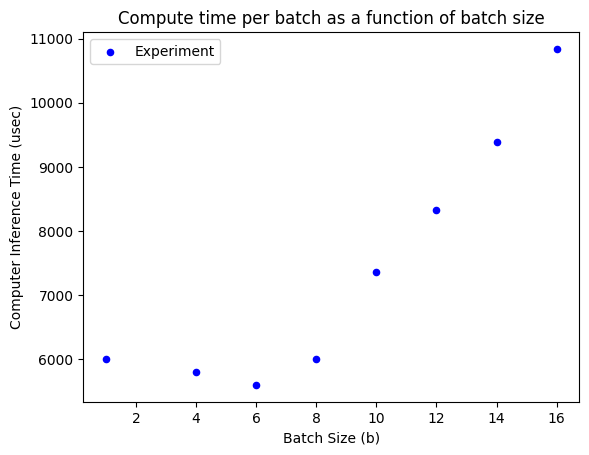

In [89]:
# Create the plot
fig, ax = plt.subplots()

df.plot.scatter(x='batch size', y='Server Compute Infer', color='blue', label='Experiment', ax=ax)
# Add legend
ax.set_title('Compute time per batch as a function of batch size')
ax.set_xlabel('Batch Size (b)')
ax.set_ylabel('Compute Inference Time (usec)')
ax.legend()
plt.legend()

# Show the plot
plt.show()

In [91]:
df["Total Compute Time"] = df['Server Compute Infer'] + df['Server Compute Input']+df['Server Compute Output']
print(df)

   Server Queue  Server Compute Input  Server Compute Infer  \
0           137                   156                  6011   
1           459                   822                  7368   
2        967909                  1083                  8323   
3       1250052                  1195                  9394   
4       5489924                  1233                 10840   
5           241                   495                  5808   
6           123                   695                  5600   
7           200                   572                  6010   

   Server Compute Output  batch size  Total Compute Time  
0                     25           1                6192  
1                     15          10                8205  
2                     21          12                9427  
3                     20          14               10609  
4                     28          16               12101  
5                     24           4                6327  
6                  

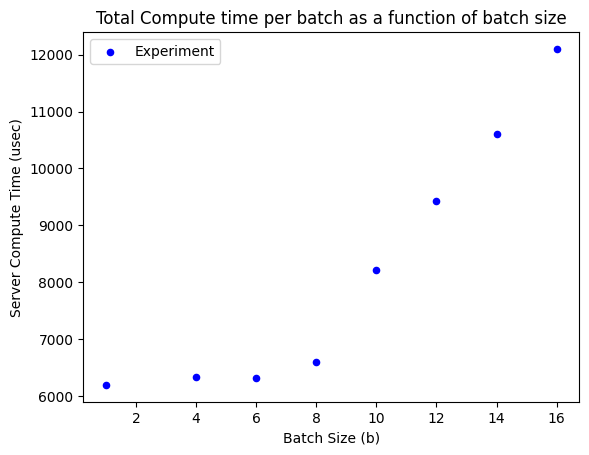

In [92]:
# Create the plot
fig, ax = plt.subplots()

df.plot.scatter(x='batch size', y='Total Compute Time', color='blue', label='Experiment', ax=ax)
# Add legend
ax.set_title('Total Compute time per batch as a function of batch size')
ax.set_xlabel('Batch Size (b)')
ax.set_ylabel('Server Compute Time (usec)')
ax.legend()
plt.legend()

# Show the plot
plt.show()

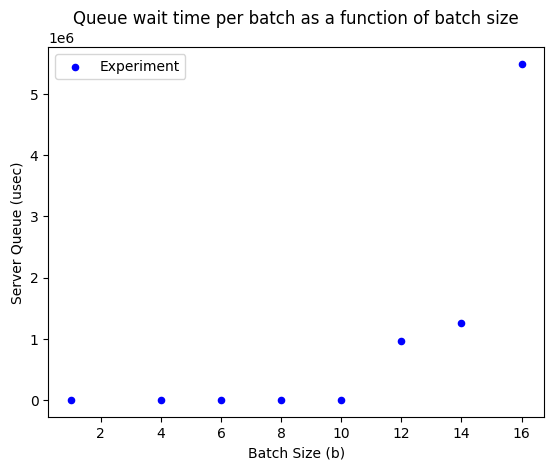

In [93]:
# Create the plot
fig, ax = plt.subplots()

df.plot.scatter(x='batch size', y='Server Queue', color='blue', label='Experiment', ax=ax)
# Add legend
ax.set_title('Queue wait time per batch as a function of batch size')
ax.set_xlabel('Batch Size (b)')
ax.set_ylabel('Server Queue (usec)')
ax.legend()
plt.legend()

# Show the plot
plt.show()

## Dynamic batching with 0.8 arrival rate

In [ ]:
import json
import matplotlib.pyplot as plt

In [2]:
import json


In [12]:
json_input = {"model_stats":[{"name":"food_classifier_onnx","version":"1","last_inference":1752520379863,"inference_count":65676,"execution_count":26143,"inference_stats":{"success":{"count":65676,"ns":16398167533574},"fail":{"count":0,"ns":0},"queue":{"count":65676,"ns":16170544788576},"compute_input":{"count":65676,"ns":63671058357},"compute_infer":{"count":65676,"ns":160340058509},"compute_output":{"count":65676,"ns":965886482},"cache_hit":{"count":0,"ns":0},"cache_miss":{"count":0,"ns":0}},"response_stats":{},"batch_stats":[{"batch_size":1,"compute_input":{"count":11387,"ns":1680892048},"compute_infer":{"count":11387,"ns":23615000207},"compute_output":{"count":11387,"ns":103180849}},{"batch_size":2,"compute_input":{"count":5689,"ns":3225072651},"compute_infer":{"count":5689,"ns":10677292419},"compute_output":{"count":5689,"ns":63468000}},{"batch_size":3,"compute_input":{"count":3497,"ns":3204112234},"compute_infer":{"count":3497,"ns":6911102658},"compute_output":{"count":3497,"ns":46424694}},{"batch_size":4,"compute_input":{"count":1944,"ns":2524527757},"compute_infer":{"count":1944,"ns":4324794494},"compute_output":{"count":1944,"ns":30174721}},{"batch_size":5,"compute_input":{"count":1049,"ns":1757674285},"compute_infer":{"count":1049,"ns":2868796223},"compute_output":{"count":1049,"ns":18551336}},{"batch_size":6,"compute_input":{"count":480,"ns":901436478},"compute_infer":{"count":480,"ns":1905374707},"compute_output":{"count":480,"ns":9398615}},{"batch_size":7,"compute_input":{"count":257,"ns":550184280},"compute_infer":{"count":257,"ns":1471413539},"compute_output":{"count":257,"ns":5608583}},{"batch_size":8,"compute_input":{"count":1840,"ns":2222661628},"compute_infer":{"count":1840,"ns":5157732923},"compute_output":{"count":1840,"ns":35923527}}],"memory_usage":[]}]}

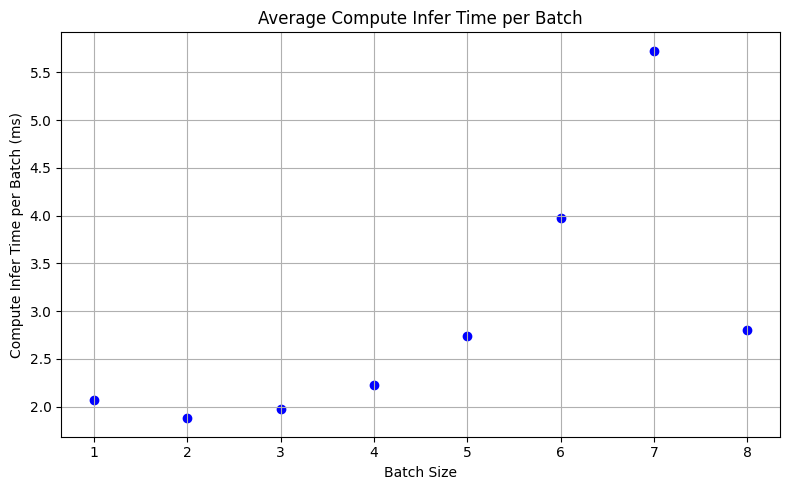

In [13]:
# Extract compute infer time per batch
batch_stats = json_input["model_stats"][0]["batch_stats"]
batch_sizes = [entry["batch_size"] for entry in batch_stats]
compute_infer_time_per_batch_ms = [
    entry["compute_infer"]["ns"] / entry["compute_infer"]["count"] / 1e6
    for entry in batch_stats
]

# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(batch_sizes, compute_infer_time_per_batch_ms, color='blue')
plt.xlabel("Batch Size")
plt.ylabel("Compute Infer Time per Batch (ms)")
plt.title("Average Compute Infer Time per Batch")
plt.grid(True)
plt.tight_layout()
plt.show()

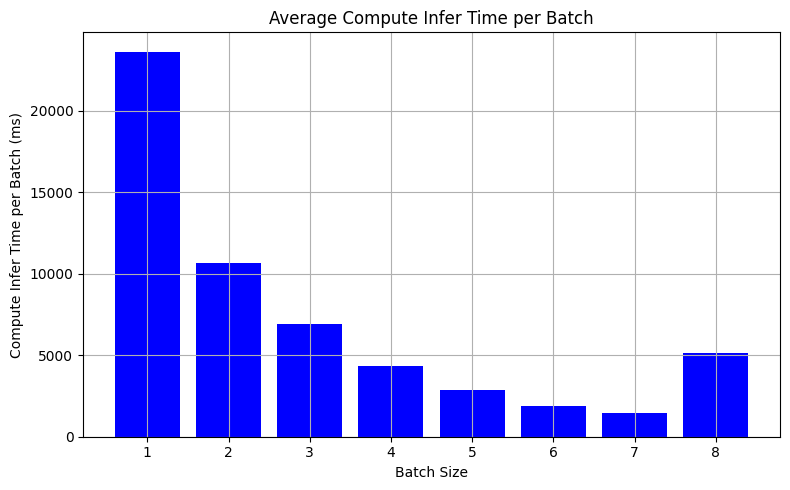

In [14]:
plt.figure(figsize=(8, 5))
compute_infer_time = [
    entry["compute_infer"]["ns"] /1e6
    for entry in batch_stats
]

plt.bar(batch_sizes, compute_infer_time, color='blue')
plt.xlabel("Batch Size")
plt.ylabel("Compute Infer Time per Batch (ms)")
plt.title("Average Compute Infer Time per Batch")
plt.grid(True)
plt.tight_layout()
plt.show()

## Examining captured requests

In [39]:
req = pd.read_csv("timestamp_requests.csv")
res = pd.read_csv("timestamp_responses.csv")

In [21]:
req.columns = ['stream', 'request_time']
res.columns = ['stream', 'response_time']

In [22]:
df = pd.merge(req, res, on='stream')

In [23]:
df['latency'] = df['response_time'] - df['request_time']

In [24]:
print(df)

           stream  request_time  response_time   latency
0              28      2.505839       3.902791  1.396952
1              28      2.505839       5.754998  3.249159
2              28      2.505839       7.268087  4.762248
3              28      2.505839       8.773764  6.267925
4              28      2.505839      10.087840  7.582001
...           ...           ...            ...       ...
163504303    4974     79.246451      79.212184 -0.034267
163504304    4974     79.246451      79.219963 -0.026488
163504305    4974     79.246451      79.227802 -0.018649
163504306    4974     79.246451      79.241810 -0.004641
163504307    4974     79.246451      79.249872  0.003421

[163504308 rows x 4 columns]


In [25]:
missing_responses = set(req['stream']) - set(res['stream'])
print(f"Missing responses for {len(missing_responses)} streams")


Missing responses for 23 streams


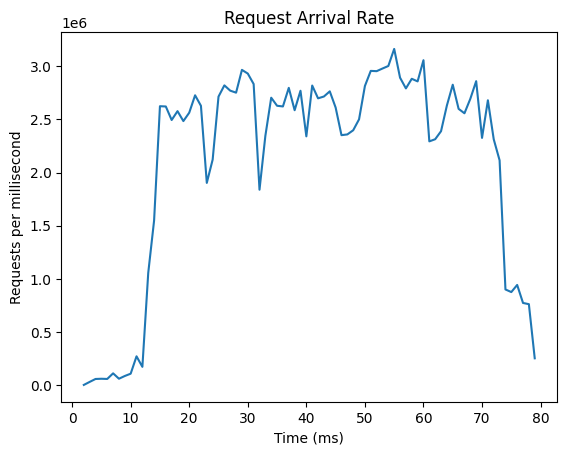

In [42]:
df['time_bin'] = df['request_time'].astype(int)
rps = df.groupby('time_bin').size()

rps.plot()
plt.xlabel("Time (ms)")
plt.ylabel("Requests per millisecond")
plt.title("Request Arrival Rate")
plt.show()

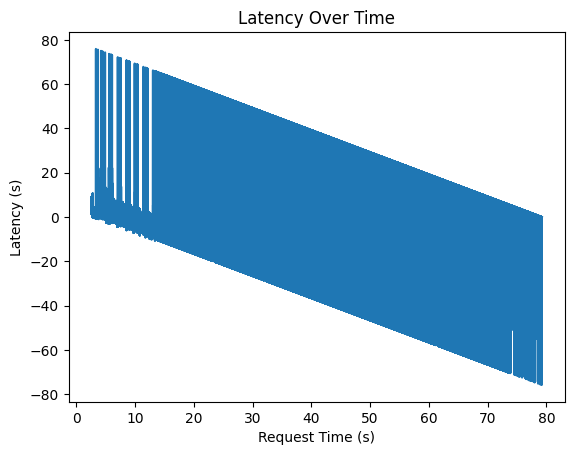

In [41]:
#latency over time

plt.plot(df['request_time'], df['latency'])
plt.xlabel("Request Time (s)")
plt.ylabel("Latency (s)")
plt.title("Latency Over Time")
plt.show()

In [43]:
import json


In [44]:
json_input ={"model_stats":[{"name":"food_classifier_onnx","version":"1","last_inference":1752699848798,"inference_count":67974,"execution_count":26989,"inference_stats":{"success":{"count":67974,"ns":18421750068645},"fail":{"count":0,"ns":0},"queue":{"count":67974,"ns":18186931050417},"compute_input":{"count":67974,"ns":61407368415},"compute_infer":{"count":67974,"ns":169625886108},"compute_output":{"count":67974,"ns":1045055987},"cache_hit":{"count":0,"ns":0},"cache_miss":{"count":0,"ns":0}},"response_stats":{},"batch_stats":[{"batch_size":1,"compute_input":{"count":11602,"ns":2000714914},"compute_infer":{"count":11602,"ns":25281562711},"compute_output":{"count":11602,"ns":101410023}},{"batch_size":2,"compute_input":{"count":5967,"ns":2998252400},"compute_infer":{"count":5967,"ns":11491365166},"compute_output":{"count":5967,"ns":63176482}},{"batch_size":3,"compute_input":{"count":3707,"ns":2949454071},"compute_infer":{"count":3707,"ns":7552313410},"compute_output":{"count":3707,"ns":45866224}},{"batch_size":4,"compute_input":{"count":2069,"ns":2209272666},"compute_infer":{"count":2069,"ns":4690752520},"compute_output":{"count":2069,"ns":29809963}},{"batch_size":5,"compute_input":{"count":1026,"ns":1389399300},"compute_infer":{"count":1026,"ns":2893939795},"compute_output":{"count":1026,"ns":16927329}},{"batch_size":6,"compute_input":{"count":418,"ns":659512730},"compute_infer":{"count":418,"ns":1835259911},"compute_output":{"count":418,"ns":7672988}},{"batch_size":7,"compute_input":{"count":197,"ns":354048048},"compute_infer":{"count":197,"ns":1381640310},"compute_output":{"count":197,"ns":4094705}},{"batch_size":8,"compute_input":{"count":2003,"ns":2792785826},"compute_infer":{"count":2003,"ns":5598612768},"compute_output":{"count":2003,"ns":50139621}}],"memory_usage":[]}]}

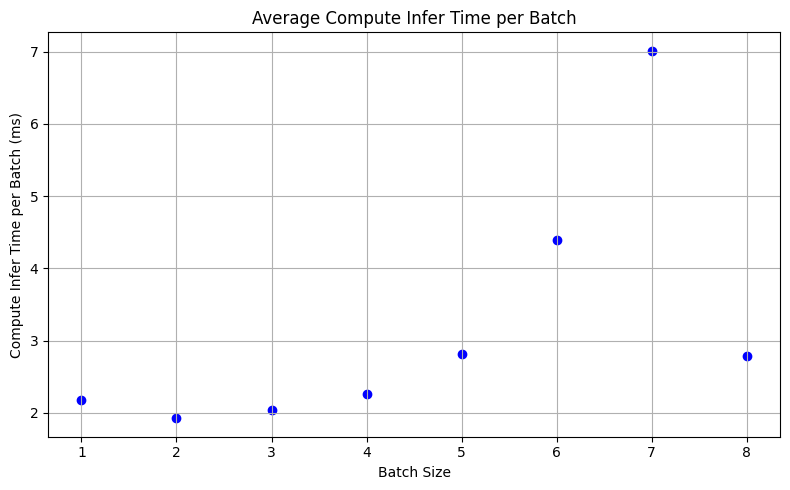

In [45]:
# Extract compute infer time per batch
batch_stats = json_input["model_stats"][0]["batch_stats"]
batch_sizes = [entry["batch_size"] for entry in batch_stats]
compute_infer_time_per_batch_ms = [
    entry["compute_infer"]["ns"] / entry["compute_infer"]["count"] / 1e6
    for entry in batch_stats
]

# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(batch_sizes, compute_infer_time_per_batch_ms, color='blue')
plt.xlabel("Batch Size")
plt.ylabel("Compute Infer Time per Batch (ms)")
plt.title("Average Compute Infer Time per Batch")
plt.grid(True)
plt.tight_layout()
plt.show()

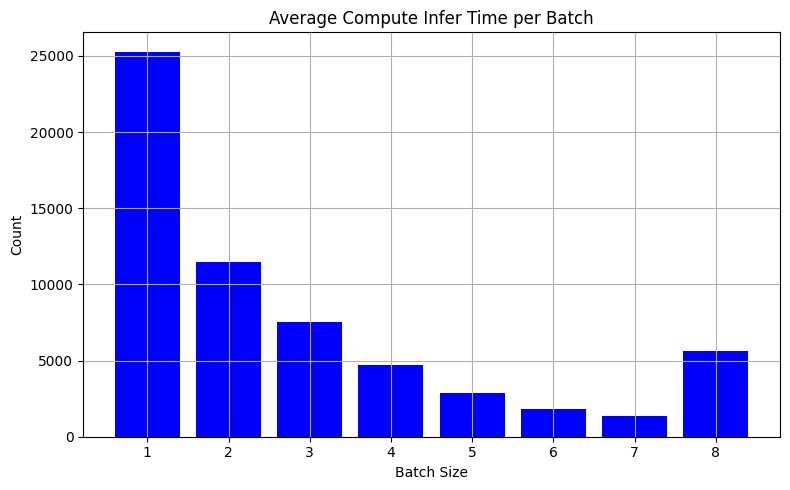

In [46]:
plt.figure(figsize=(8, 5))
compute_infer_time = [
    entry["compute_infer"]["ns"] /1e6
    for entry in batch_stats
]

plt.bar(batch_sizes, compute_infer_time, color='blue')
plt.xlabel("Batch Size")
plt.ylabel("Count")
plt.title("Average Compute Infer Time per Batch")
plt.grid(True)
plt.tight_layout()
plt.show()

In [47]:
json_input ={"model_stats":[{"name":"food_classifier_onnx","version":"1","last_inference":1752700758323,"inference_count":82623,"execution_count":37475,"inference_stats":{"success":{"count":82623,"ns":18471792767292},"fail":{"count":0,"ns":0},"queue":{"count":82623,"ns":18199754767871},"compute_input":{"count":82623,"ns":69801195028},"compute_infer":{"count":82623,"ns":197995029778},"compute_output":{"count":82623,"ns":1190070360},"cache_hit":{"count":0,"ns":0},"cache_miss":{"count":0,"ns":0}},"response_stats":{},"batch_stats":[{"batch_size":1,"compute_input":{"count":19248,"ns":4072310950},"compute_infer":{"count":19248,"ns":40533030902},"compute_output":{"count":19248,"ns":167286673}},{"batch_size":2,"compute_input":{"count":7872,"ns":4258994850},"compute_infer":{"count":7872,"ns":15027462777},"compute_output":{"count":7872,"ns":82244486}},{"batch_size":3,"compute_input":{"count":4371,"ns":3607081623},"compute_infer":{"count":4371,"ns":8796998745},"compute_output":{"count":4371,"ns":53581288}},{"batch_size":4,"compute_input":{"count":2267,"ns":2481798674},"compute_infer":{"count":2267,"ns":5062393627},"compute_output":{"count":2267,"ns":32489896}},{"batch_size":5,"compute_input":{"count":1073,"ns":1470682145},"compute_infer":{"count":1073,"ns":2984588044},"compute_output":{"count":1073,"ns":17662300}},{"batch_size":6,"compute_input":{"count":433,"ns":688379387},"compute_infer":{"count":433,"ns":1865923133},"compute_output":{"count":433,"ns":7950744}},{"batch_size":7,"compute_input":{"count":201,"ns":361201250},"compute_infer":{"count":201,"ns":1390202247},"compute_output":{"count":201,"ns":4171801}},{"batch_size":8,"compute_input":{"count":2010,"ns":2806294877},"compute_infer":{"count":2010,"ns":5614575979},"compute_output":{"count":2010,"ns":50296587}}],"memory_usage":[]}]}

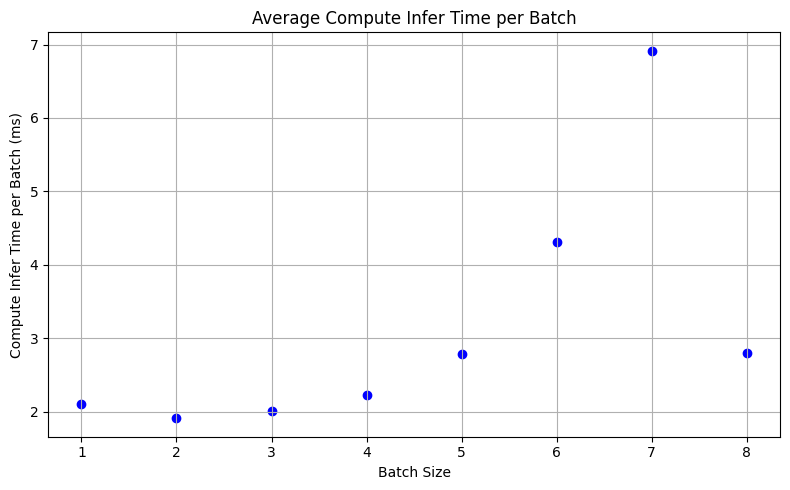

In [48]:
# Extract compute infer time per batch
batch_stats = json_input["model_stats"][0]["batch_stats"]
batch_sizes = [entry["batch_size"] for entry in batch_stats]
compute_infer_time_per_batch_ms = [
    entry["compute_infer"]["ns"] / entry["compute_infer"]["count"] / 1e6
    for entry in batch_stats
]

# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(batch_sizes, compute_infer_time_per_batch_ms, color='blue')
plt.xlabel("Batch Size")
plt.ylabel("Compute Infer Time per Batch (ms)")
plt.title("Average Compute Infer Time per Batch")
plt.grid(True)
plt.tight_layout()
plt.show()

In [49]:
json_input ={"model_stats":[{"name":"food_classifier_onnx","version":"1","last_inference":1752701104209,"inference_count":28733,"execution_count":13899,"inference_stats":{"success":{"count":28733,"ns":9452307608236},"fail":{"count":0,"ns":0},"queue":{"count":28733,"ns":8997976881043},"compute_input":{"count":28733,"ns":72810767546},"compute_infer":{"count":28733,"ns":377668118671},"compute_output":{"count":28733,"ns":942602185},"cache_hit":{"count":0,"ns":0},"cache_miss":{"count":0,"ns":0}},"response_stats":{},"batch_stats":[{"batch_size":1,"compute_input":{"count":10200,"ns":2322701020},"compute_infer":{"count":10200,"ns":22818035704},"compute_output":{"count":10200,"ns":85404885}},{"batch_size":2,"compute_input":{"count":2298,"ns":1443412247},"compute_infer":{"count":2298,"ns":5205614922},"compute_output":{"count":2298,"ns":22554938}},{"batch_size":3,"compute_input":{"count":764,"ns":760244447},"compute_infer":{"count":764,"ns":2389860437},"compute_output":{"count":764,"ns":8555878}},{"batch_size":4,"compute_input":{"count":230,"ns":298397109},"compute_infer":{"count":230,"ns":1388562626},"compute_output":{"count":230,"ns":2882073}},{"batch_size":5,"compute_input":{"count":52,"ns":76023463},"compute_infer":{"count":52,"ns":1059587423},"compute_output":{"count":52,"ns":755466}},{"batch_size":6,"compute_input":{"count":15,"ns":31295325},"compute_infer":{"count":15,"ns":991681237},"compute_output":{"count":15,"ns":284490}},{"batch_size":7,"compute_input":{"count":8,"ns":12852963},"compute_infer":{"count":8,"ns":985535807},"compute_output":{"count":8,"ns":172714}},{"batch_size":8,"compute_input":{"count":3,"ns":7419318},"compute_infer":{"count":3,"ns":955974736},"compute_output":{"count":3,"ns":64270}},{"batch_size":9,"compute_input":{"count":2,"ns":4327585},"compute_infer":{"count":2,"ns":980124904},"compute_output":{"count":2,"ns":96782}},{"batch_size":10,"compute_input":{"count":3,"ns":5760794},"compute_infer":{"count":3,"ns":1002980995},"compute_output":{"count":3,"ns":135255}},{"batch_size":13,"compute_input":{"count":1,"ns":3965432},"compute_infer":{"count":1,"ns":1015422100},"compute_output":{"count":1,"ns":52619}},{"batch_size":14,"compute_input":{"count":2,"ns":3272142},"compute_infer":{"count":2,"ns":1038205856},"compute_output":{"count":2,"ns":106911}},{"batch_size":20,"compute_input":{"count":1,"ns":2917312},"compute_infer":{"count":1,"ns":1072966509},"compute_output":{"count":1,"ns":102473}},{"batch_size":23,"compute_input":{"count":4,"ns":13829547},"compute_infer":{"count":4,"ns":1120588543},"compute_output":{"count":4,"ns":270610}},{"batch_size":25,"compute_input":{"count":1,"ns":6448233},"compute_infer":{"count":1,"ns":1124727912},"compute_output":{"count":1,"ns":170432}},{"batch_size":27,"compute_input":{"count":1,"ns":3549456},"compute_infer":{"count":1,"ns":1126336771},"compute_output":{"count":1,"ns":143611}},{"batch_size":28,"compute_input":{"count":1,"ns":3403761},"compute_infer":{"count":1,"ns":1099182258},"compute_output":{"count":1,"ns":126219}},{"batch_size":30,"compute_input":{"count":1,"ns":6707813},"compute_infer":{"count":1,"ns":1151302239},"compute_output":{"count":1,"ns":225887}},{"batch_size":32,"compute_input":{"count":312,"ns":1946430695},"compute_infer":{"count":312,"ns":2757994287},"compute_output":{"count":312,"ns":23017411}}],"memory_usage":[]}]}

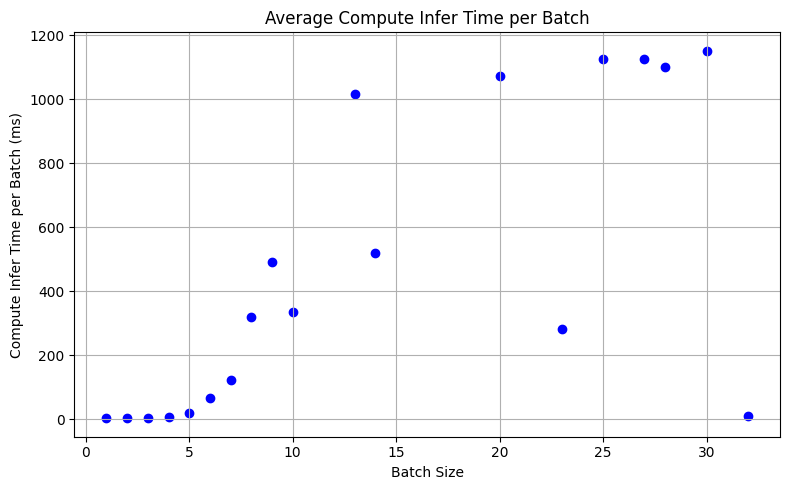

In [50]:
# Extract compute infer time per batch
batch_stats = json_input["model_stats"][0]["batch_stats"]
batch_sizes = [entry["batch_size"] for entry in batch_stats]
compute_infer_time_per_batch_ms = [
    entry["compute_infer"]["ns"] / entry["compute_infer"]["count"] / 1e6
    for entry in batch_stats
]

# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(batch_sizes, compute_infer_time_per_batch_ms, color='blue')
plt.xlabel("Batch Size")
plt.ylabel("Compute Infer Time per Batch (ms)")
plt.title("Average Compute Infer Time per Batch")
plt.grid(True)
plt.tight_layout()
plt.show()

Config is dynamic batching{max queue delay = 100 μsec}

In [51]:
json_input ={"model_stats":[{"name":"food_classifier_onnx","version":"1","last_inference":1752777914560,"inference_count":27228,"execution_count":13548,"inference_stats":{"success":{"count":27228,"ns":9965576408105},"fail":{"count":0,"ns":0},"queue":{"count":27228,"ns":9477247114701},"compute_input":{"count":27228,"ns":58060624964},"compute_infer":{"count":27228,"ns":426668246175},"compute_output":{"count":27228,"ns":881853238},"cache_hit":{"count":0,"ns":0},"cache_miss":{"count":0,"ns":0}},"response_stats":{},"batch_stats":[{"batch_size":1,"compute_input":{"count":10687,"ns":634669749},"compute_infer":{"count":10687,"ns":22568359397},"compute_output":{"count":10687,"ns":88810495}},{"batch_size":2,"compute_input":{"count":2054,"ns":1192569974},"compute_infer":{"count":2054,"ns":4576926297},"compute_output":{"count":2054,"ns":19497228}},{"batch_size":3,"compute_input":{"count":344,"ns":290920592},"compute_infer":{"count":344,"ns":1497010486},"compute_output":{"count":344,"ns":3653133}},{"batch_size":4,"compute_input":{"count":88,"ns":94250296},"compute_infer":{"count":88,"ns":1027315645},"compute_output":{"count":88,"ns":1094038}},{"batch_size":5,"compute_input":{"count":21,"ns":27012823},"compute_infer":{"count":21,"ns":960156911},"compute_output":{"count":21,"ns":307007}},{"batch_size":6,"compute_input":{"count":4,"ns":5723549},"compute_infer":{"count":4,"ns":909976564},"compute_output":{"count":4,"ns":79121}},{"batch_size":7,"compute_input":{"count":2,"ns":3923660},"compute_infer":{"count":2,"ns":887214669},"compute_output":{"count":2,"ns":49403}},{"batch_size":8,"compute_input":{"count":1,"ns":817654},"compute_infer":{"count":1,"ns":892024963},"compute_output":{"count":1,"ns":33283}},{"batch_size":9,"compute_input":{"count":1,"ns":2591955},"compute_infer":{"count":1,"ns":982084959},"compute_output":{"count":1,"ns":31329}},{"batch_size":11,"compute_input":{"count":3,"ns":3400332},"compute_infer":{"count":3,"ns":1014350954},"compute_output":{"count":3,"ns":102014}},{"batch_size":14,"compute_input":{"count":1,"ns":1293453},"compute_infer":{"count":1,"ns":1052935140},"compute_output":{"count":1,"ns":86984}},{"batch_size":17,"compute_input":{"count":1,"ns":1576617},"compute_infer":{"count":1,"ns":1079434114},"compute_output":{"count":1,"ns":114907}},{"batch_size":18,"compute_input":{"count":1,"ns":4608904},"compute_infer":{"count":1,"ns":1049887335},"compute_output":{"count":1,"ns":58059}},{"batch_size":21,"compute_input":{"count":1,"ns":2009725},"compute_infer":{"count":1,"ns":1089076112},"compute_output":{"count":1,"ns":60795}},{"batch_size":22,"compute_input":{"count":3,"ns":9740325},"compute_infer":{"count":3,"ns":1095988797},"compute_output":{"count":3,"ns":169440}},{"batch_size":23,"compute_input":{"count":1,"ns":2037007},"compute_infer":{"count":1,"ns":1075269018},"compute_output":{"count":1,"ns":65904}},{"batch_size":26,"compute_input":{"count":1,"ns":2482889},"compute_infer":{"count":1,"ns":1098460775},"compute_output":{"count":1,"ns":97865}},{"batch_size":28,"compute_input":{"count":1,"ns":2593138},"compute_infer":{"count":1,"ns":1107450682},"compute_output":{"count":1,"ns":90491}},{"batch_size":29,"compute_input":{"count":3,"ns":7983265},"compute_infer":{"count":3,"ns":1128110930},"compute_output":{"count":3,"ns":241766}},{"batch_size":31,"compute_input":{"count":4,"ns":14601735},"compute_infer":{"count":4,"ns":1143171901},"compute_output":{"count":4,"ns":293725}},{"batch_size":32,"compute_input":{"count":326,"ns":1633573866},"compute_infer":{"count":326,"ns":2853645010},"compute_output":{"count":326,"ns":21961107}}],"memory_usage":[]}]}

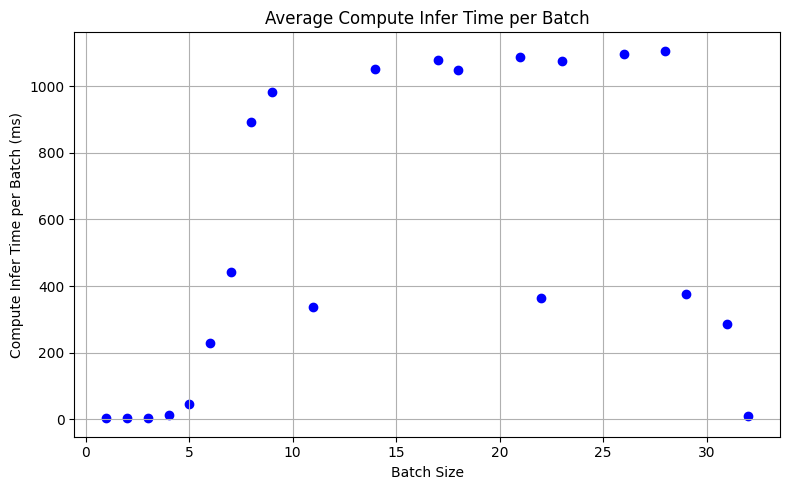

In [52]:
# Extract compute infer time per batch
batch_stats = json_input["model_stats"][0]["batch_stats"]
batch_sizes = [entry["batch_size"] for entry in batch_stats]
compute_infer_time_per_batch_ms = [
    entry["compute_infer"]["ns"] / entry["compute_infer"]["count"] / 1e6
    for entry in batch_stats
]

# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(batch_sizes, compute_infer_time_per_batch_ms, color='blue')
plt.xlabel("Batch Size")
plt.ylabel("Compute Infer Time per Batch (ms)")
plt.title("Average Compute Infer Time per Batch")
plt.grid(True)
plt.tight_layout()
plt.show()

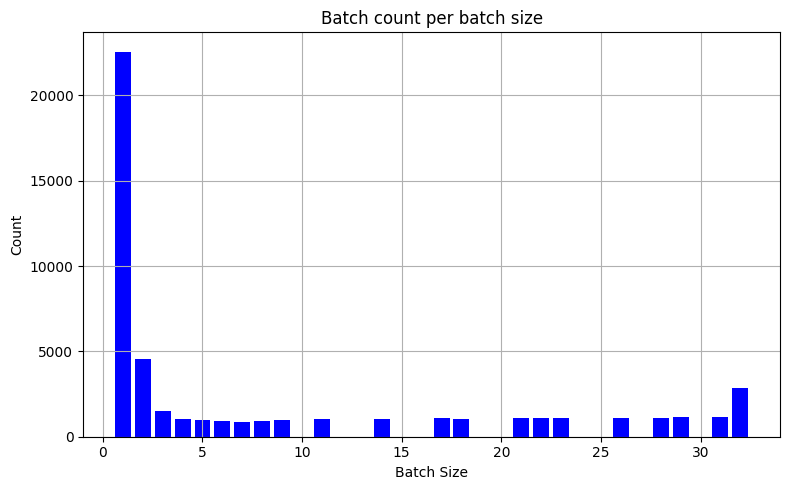

In [53]:
plt.figure(figsize=(8, 5))
compute_infer_time = [
    entry["compute_infer"]["ns"] /1e6
    for entry in batch_stats
]

plt.bar(batch_sizes, compute_infer_time, color='blue')
plt.xlabel("Batch Size")
plt.ylabel("Count")
plt.title("Batch count per batch size")
plt.grid(True)
plt.tight_layout()
plt.show()

now with max batch size = 64

In [54]:
json_input ={"model_stats":[{"name":"food_classifier_onnx","version":"1","last_inference":1752778339459,"inference_count":27053,"execution_count":8257,"inference_stats":{"success":{"count":27053,"ns":17231648855778},"fail":{"count":0,"ns":0},"queue":{"count":27053,"ns":15762225734606},"compute_input":{"count":27053,"ns":211964038356},"compute_infer":{"count":27053,"ns":1244678289940},"compute_output":{"count":27053,"ns":3068408468},"cache_hit":{"count":0,"ns":0},"cache_miss":{"count":0,"ns":0}},"response_stats":{},"batch_stats":[{"batch_size":1,"compute_input":{"count":6599,"ns":541718794},"compute_infer":{"count":6599,"ns":14487226052},"compute_output":{"count":6599,"ns":57454221}},{"batch_size":2,"compute_input":{"count":1123,"ns":306788082},"compute_infer":{"count":1123,"ns":2912599696},"compute_output":{"count":1123,"ns":11712545}},{"batch_size":3,"compute_input":{"count":189,"ns":91561301},"compute_infer":{"count":189,"ns":1280600669},"compute_output":{"count":189,"ns":2337190}},{"batch_size":4,"compute_input":{"count":45,"ns":30492318},"compute_infer":{"count":45,"ns":1022302665},"compute_output":{"count":45,"ns":878632}},{"batch_size":5,"compute_input":{"count":7,"ns":6051150},"compute_infer":{"count":7,"ns":973087576},"compute_output":{"count":7,"ns":146004}},{"batch_size":6,"compute_input":{"count":5,"ns":3936996},"compute_infer":{"count":5,"ns":986133153},"compute_output":{"count":5,"ns":205317}},{"batch_size":7,"compute_input":{"count":1,"ns":1014867},"compute_infer":{"count":1,"ns":967768009},"compute_output":{"count":1,"ns":55435}},{"batch_size":9,"compute_input":{"count":3,"ns":4015232},"compute_infer":{"count":3,"ns":984350435},"compute_output":{"count":3,"ns":153860}},{"batch_size":13,"compute_input":{"count":2,"ns":10172261},"compute_infer":{"count":2,"ns":1024022588},"compute_output":{"count":2,"ns":135365}},{"batch_size":16,"compute_input":{"count":3,"ns":12729610},"compute_infer":{"count":3,"ns":1060084202},"compute_output":{"count":3,"ns":210348}},{"batch_size":17,"compute_input":{"count":1,"ns":7447144},"compute_infer":{"count":1,"ns":1063073097},"compute_output":{"count":1,"ns":107172}},{"batch_size":22,"compute_input":{"count":1,"ns":3587355},"compute_infer":{"count":1,"ns":1088020410},"compute_output":{"count":1,"ns":127090}},{"batch_size":23,"compute_input":{"count":1,"ns":2496145},"compute_infer":{"count":1,"ns":1088953793},"compute_output":{"count":1,"ns":189247}},{"batch_size":26,"compute_input":{"count":3,"ns":16328809},"compute_infer":{"count":3,"ns":1105565776},"compute_output":{"count":3,"ns":436863}},{"batch_size":29,"compute_input":{"count":1,"ns":4084063},"compute_infer":{"count":1,"ns":1125806010},"compute_output":{"count":1,"ns":162096}},{"batch_size":30,"compute_input":{"count":1,"ns":4103280},"compute_infer":{"count":1,"ns":1128425346},"compute_output":{"count":1,"ns":213954}},{"batch_size":31,"compute_input":{"count":1,"ns":4757374},"compute_infer":{"count":1,"ns":1141023499},"compute_output":{"count":1,"ns":156355}},{"batch_size":32,"compute_input":{"count":1,"ns":4735953},"compute_infer":{"count":1,"ns":1126226825},"compute_output":{"count":1,"ns":125397}},{"batch_size":34,"compute_input":{"count":1,"ns":3912449},"compute_infer":{"count":1,"ns":1161153135},"compute_output":{"count":1,"ns":147118}},{"batch_size":35,"compute_input":{"count":2,"ns":14058371},"compute_infer":{"count":2,"ns":1171873419},"compute_output":{"count":2,"ns":357765}},{"batch_size":36,"compute_input":{"count":1,"ns":5337870},"compute_infer":{"count":1,"ns":1167374985},"compute_output":{"count":1,"ns":193966}},{"batch_size":37,"compute_input":{"count":1,"ns":5048254},"compute_infer":{"count":1,"ns":1162017306},"compute_output":{"count":1,"ns":252928}},{"batch_size":39,"compute_input":{"count":1,"ns":4726807},"compute_infer":{"count":1,"ns":1200600914},"compute_output":{"count":1,"ns":345051}},{"batch_size":45,"compute_input":{"count":1,"ns":5331258},"compute_infer":{"count":1,"ns":1210533401},"compute_output":{"count":1,"ns":267756}},{"batch_size":50,"compute_input":{"count":1,"ns":7112191},"compute_infer":{"count":1,"ns":1228613186},"compute_output":{"count":1,"ns":408692}},{"batch_size":51,"compute_input":{"count":2,"ns":14732101},"compute_infer":{"count":2,"ns":1241930527},"compute_output":{"count":2,"ns":338639}},{"batch_size":56,"compute_input":{"count":1,"ns":8418739},"compute_infer":{"count":1,"ns":1260749106},"compute_output":{"count":1,"ns":279788}},{"batch_size":59,"compute_input":{"count":2,"ns":22222679},"compute_infer":{"count":2,"ns":1271912337},"compute_output":{"count":2,"ns":421396}},{"batch_size":60,"compute_input":{"count":2,"ns":16525058},"compute_infer":{"count":2,"ns":1281233452},"compute_output":{"count":2,"ns":682088}},{"batch_size":63,"compute_input":{"count":1,"ns":9144459},"compute_infer":{"count":1,"ns":1278434786},"compute_output":{"count":1,"ns":291270}},{"batch_size":64,"compute_input":{"count":254,"ns":3169775057},"compute_infer":{"count":254,"ns":3615505253},"compute_output":{"count":254,"ns":42671141}}],"memory_usage":[]}]}

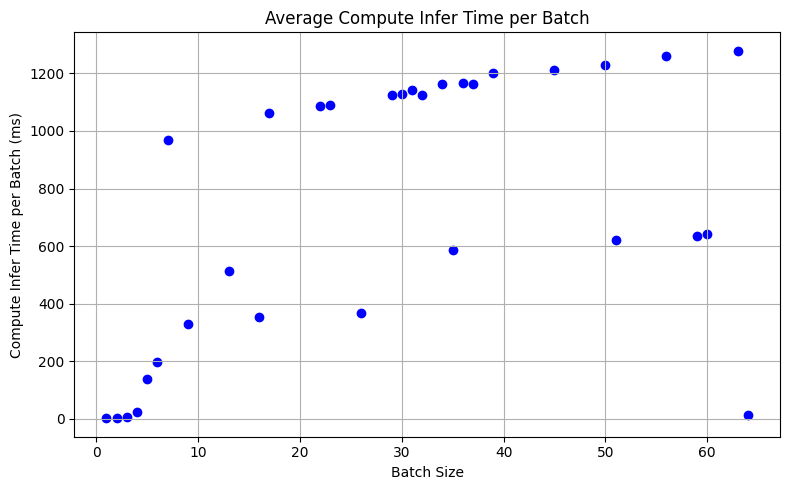

In [55]:
# Extract compute infer time per batch
batch_stats = json_input["model_stats"][0]["batch_stats"]
batch_sizes = [entry["batch_size"] for entry in batch_stats]
compute_infer_time_per_batch_ms = [
    entry["compute_infer"]["ns"] / entry["compute_infer"]["count"] / 1e6
    for entry in batch_stats
]

# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(batch_sizes, compute_infer_time_per_batch_ms, color='blue')
plt.xlabel("Batch Size")
plt.ylabel("Compute Infer Time per Batch (ms)")
plt.title("Average Compute Infer Time per Batch")
plt.grid(True)
plt.tight_layout()
plt.show()

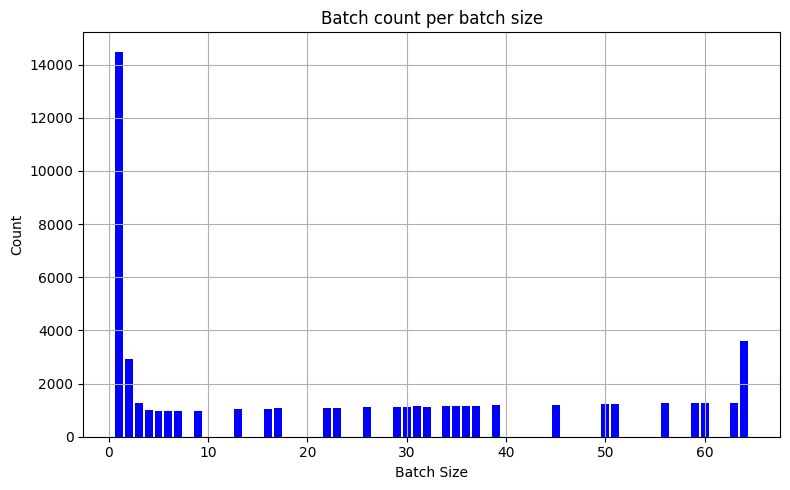

In [56]:
plt.figure(figsize=(8, 5))
compute_infer_time = [
    entry["compute_infer"]["ns"] /1e6
    for entry in batch_stats
]

plt.bar(batch_sizes, compute_infer_time, color='blue')
plt.xlabel("Batch Size")
plt.ylabel("Count")
plt.title("Batch count per batch size")
plt.grid(True)
plt.tight_layout()
plt.show()

In [57]:
json_input ={"model_stats":[{"name":"food_classifier_onnx","version":"1","last_inference":1752861305182,"inference_count":28317,"execution_count":5663,"inference_stats":{"success":{"count":28317,"ns":19975049060535},"fail":{"count":0,"ns":0},"queue":{"count":28317,"ns":18105283612900},"compute_input":{"count":28317,"ns":266919171598},"compute_infer":{"count":28317,"ns":1591277427035},"compute_output":{"count":28317,"ns":2506119665},"cache_hit":{"count":0,"ns":0},"cache_miss":{"count":0,"ns":0}},"response_stats":{},"batch_stats":[{"batch_size":1,"compute_input":{"count":4184,"ns":975918137},"compute_infer":{"count":4184,"ns":11430506797},"compute_output":{"count":4184,"ns":37115351}},{"batch_size":2,"compute_input":{"count":855,"ns":510165689},"compute_infer":{"count":855,"ns":2589213908},"compute_output":{"count":855,"ns":8674727}},{"batch_size":3,"compute_input":{"count":195,"ns":173422303},"compute_infer":{"count":195,"ns":1334932239},"compute_output":{"count":195,"ns":2178646}},{"batch_size":4,"compute_input":{"count":54,"ns":62877660},"compute_infer":{"count":54,"ns":1035614697},"compute_output":{"count":54,"ns":681659}},{"batch_size":5,"compute_input":{"count":14,"ns":20464668},"compute_infer":{"count":14,"ns":988338758},"compute_output":{"count":14,"ns":236075}},{"batch_size":6,"compute_input":{"count":1,"ns":3129049},"compute_infer":{"count":1,"ns":992739568},"compute_output":{"count":1,"ns":40286}},{"batch_size":7,"compute_input":{"count":1,"ns":862589},"compute_infer":{"count":1,"ns":927325330},"compute_output":{"count":1,"ns":36409}},{"batch_size":8,"compute_input":{"count":3,"ns":3187940},"compute_infer":{"count":3,"ns":937269068},"compute_output":{"count":3,"ns":113616}},{"batch_size":9,"compute_input":{"count":2,"ns":3094635},"compute_infer":{"count":2,"ns":997534913},"compute_output":{"count":2,"ns":70162}},{"batch_size":10,"compute_input":{"count":2,"ns":2558631},"compute_infer":{"count":2,"ns":999648055},"compute_output":{"count":2,"ns":88877}},{"batch_size":11,"compute_input":{"count":1,"ns":1209414},"compute_infer":{"count":1,"ns":981512024},"compute_output":{"count":1,"ns":74892}},{"batch_size":13,"compute_input":{"count":1,"ns":7653985},"compute_infer":{"count":1,"ns":1051124799},"compute_output":{"count":1,"ns":276863}},{"batch_size":14,"compute_input":{"count":1,"ns":5868613},"compute_infer":{"count":1,"ns":1045783532},"compute_output":{"count":1,"ns":75192}},{"batch_size":19,"compute_input":{"count":2,"ns":13164743},"compute_infer":{"count":2,"ns":1090253395},"compute_output":{"count":2,"ns":118394}},{"batch_size":20,"compute_input":{"count":2,"ns":17911046},"compute_infer":{"count":2,"ns":1078502162},"compute_output":{"count":2,"ns":147559}},{"batch_size":21,"compute_input":{"count":1,"ns":4038878},"compute_infer":{"count":1,"ns":1044469340},"compute_output":{"count":1,"ns":86153}},{"batch_size":22,"compute_input":{"count":2,"ns":6371443},"compute_infer":{"count":2,"ns":1083033019},"compute_output":{"count":2,"ns":140866}},{"batch_size":25,"compute_input":{"count":3,"ns":13961887},"compute_infer":{"count":3,"ns":1080383726},"compute_output":{"count":3,"ns":234973}},{"batch_size":27,"compute_input":{"count":1,"ns":4647747},"compute_infer":{"count":1,"ns":1113810012},"compute_output":{"count":1,"ns":79200}},{"batch_size":29,"compute_input":{"count":1,"ns":3483940},"compute_infer":{"count":1,"ns":1113409085},"compute_output":{"count":1,"ns":98827}},{"batch_size":30,"compute_input":{"count":1,"ns":5941911},"compute_infer":{"count":1,"ns":1127489897},"compute_output":{"count":1,"ns":89550}},{"batch_size":33,"compute_input":{"count":1,"ns":4047303},"compute_infer":{"count":1,"ns":1157734575},"compute_output":{"count":1,"ns":97154}},{"batch_size":35,"compute_input":{"count":2,"ns":13380931},"compute_infer":{"count":2,"ns":1183129925},"compute_output":{"count":2,"ns":176574}},{"batch_size":37,"compute_input":{"count":1,"ns":6971706},"compute_infer":{"count":1,"ns":1169113024},"compute_output":{"count":1,"ns":106320}},{"batch_size":40,"compute_input":{"count":2,"ns":12190953},"compute_infer":{"count":2,"ns":1187511500},"compute_output":{"count":2,"ns":273306}},{"batch_size":42,"compute_input":{"count":1,"ns":7021751},"compute_infer":{"count":1,"ns":1193024090},"compute_output":{"count":1,"ns":120438}},{"batch_size":43,"compute_input":{"count":2,"ns":12770096},"compute_infer":{"count":2,"ns":1210667491},"compute_output":{"count":2,"ns":213874}},{"batch_size":44,"compute_input":{"count":1,"ns":7506427},"compute_infer":{"count":1,"ns":1218671356},"compute_output":{"count":1,"ns":116439}},{"batch_size":45,"compute_input":{"count":1,"ns":7516845},"compute_infer":{"count":1,"ns":1211749124},"compute_output":{"count":1,"ns":205217}},{"batch_size":48,"compute_input":{"count":1,"ns":5798060},"compute_infer":{"count":1,"ns":1214488627},"compute_output":{"count":1,"ns":180811}},{"batch_size":50,"compute_input":{"count":1,"ns":8650697},"compute_infer":{"count":1,"ns":1222039507},"compute_output":{"count":1,"ns":151095}},{"batch_size":52,"compute_input":{"count":2,"ns":16679399},"compute_infer":{"count":2,"ns":1235552857},"compute_output":{"count":2,"ns":261173}},{"batch_size":54,"compute_input":{"count":1,"ns":7948010},"compute_infer":{"count":1,"ns":1240109622},"compute_output":{"count":1,"ns":354089}},{"batch_size":56,"compute_input":{"count":2,"ns":17799024},"compute_infer":{"count":2,"ns":1252510822},"compute_output":{"count":2,"ns":408592}},{"batch_size":57,"compute_input":{"count":1,"ns":9640557},"compute_infer":{"count":1,"ns":1258642172},"compute_output":{"count":1,"ns":141136}},{"batch_size":59,"compute_input":{"count":2,"ns":14560949},"compute_infer":{"count":2,"ns":1276201253},"compute_output":{"count":2,"ns":266043}},{"batch_size":60,"compute_input":{"count":1,"ns":10978514},"compute_infer":{"count":1,"ns":1291420525},"compute_output":{"count":1,"ns":489173}},{"batch_size":63,"compute_input":{"count":1,"ns":13530563},"compute_infer":{"count":1,"ns":1298292693},"compute_output":{"count":1,"ns":223342}},{"batch_size":64,"compute_input":{"count":313,"ns":3959047319},"compute_infer":{"count":313,"ns":4133725718},"compute_output":{"count":313,"ns":34645190}}],"memory_usage":[]}]}

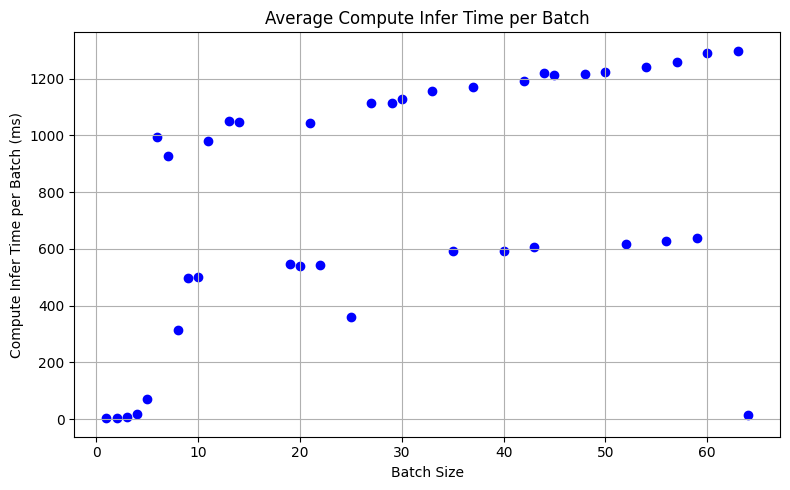

In [58]:
# Extract compute infer time per batch
batch_stats = json_input["model_stats"][0]["batch_stats"]
batch_sizes = [entry["batch_size"] for entry in batch_stats]
compute_infer_time_per_batch_ms = [
    entry["compute_infer"]["ns"] / entry["compute_infer"]["count"] / 1e6
    for entry in batch_stats
]

# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(batch_sizes, compute_infer_time_per_batch_ms, color='blue')
plt.xlabel("Batch Size")
plt.ylabel("Compute Infer Time per Batch (ms)")
plt.title("Average Compute Infer Time per Batch")
plt.grid(True)
plt.tight_layout()
plt.show()

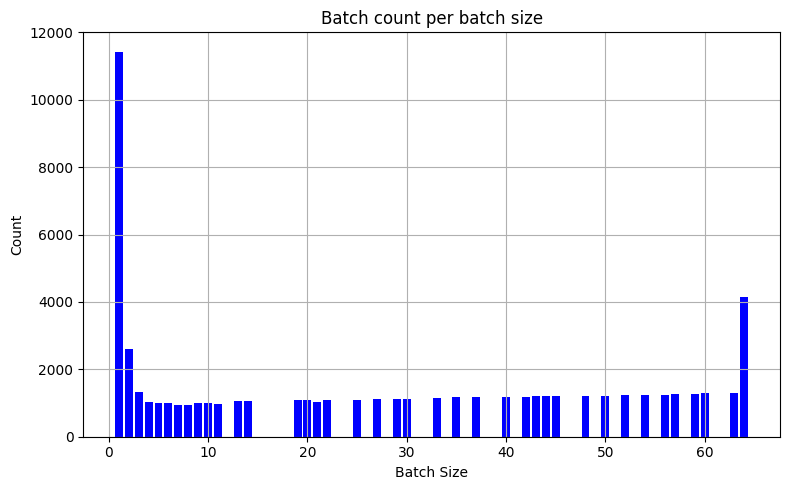

In [59]:
plt.figure(figsize=(8, 5))
compute_infer_time = [
    entry["compute_infer"]["ns"] /1e6
    for entry in batch_stats
]

plt.bar(batch_sizes, compute_infer_time, color='blue')
plt.xlabel("Batch Size")
plt.ylabel("Count")
plt.title("Batch count per batch size")
plt.grid(True)
plt.tight_layout()
plt.show()

no preferred batch size - arrival rate = 100 - max queue delay yes- max batch size 64

In [60]:
json_input ={"model_stats":[{"name":"food_classifier_onnx","version":"1","last_inference":1752861600037,"inference_count":5001,"execution_count":2276,"inference_stats":{"success":{"count":5001,"ns":4537092944084},"fail":{"count":0,"ns":0},"queue":{"count":5001,"ns":3592843563305},"compute_input":{"count":5001,"ns":33373262228},"compute_infer":{"count":5001,"ns":909136449439},"compute_output":{"count":5001,"ns":457061710},"cache_hit":{"count":0,"ns":0},"cache_miss":{"count":0,"ns":0}},"response_stats":{},"batch_stats":[{"batch_size":1,"compute_input":{"count":2095,"ns":624090595},"compute_infer":{"count":2095,"ns":10826678477},"compute_output":{"count":2095,"ns":37621917}},{"batch_size":2,"compute_input":{"count":122,"ns":90435704},"compute_infer":{"count":122,"ns":1310770734},"compute_output":{"count":122,"ns":2531502}},{"batch_size":3,"compute_input":{"count":7,"ns":6984250},"compute_infer":{"count":7,"ns":912351152},"compute_output":{"count":7,"ns":196611}},{"batch_size":4,"compute_input":{"count":3,"ns":2149278},"compute_infer":{"count":3,"ns":890710693},"compute_output":{"count":3,"ns":103686}},{"batch_size":9,"compute_input":{"count":1,"ns":5166957},"compute_infer":{"count":1,"ns":1022597435},"compute_output":{"count":1,"ns":71936}},{"batch_size":14,"compute_input":{"count":1,"ns":17493387},"compute_infer":{"count":1,"ns":1051759177},"compute_output":{"count":1,"ns":83227}},{"batch_size":15,"compute_input":{"count":1,"ns":1553283},"compute_infer":{"count":1,"ns":1011145347},"compute_output":{"count":1,"ns":56687}},{"batch_size":21,"compute_input":{"count":1,"ns":7436134},"compute_infer":{"count":1,"ns":1096026618},"compute_output":{"count":1,"ns":174219}},{"batch_size":35,"compute_input":{"count":1,"ns":7299155},"compute_infer":{"count":1,"ns":1141628167},"compute_output":{"count":1,"ns":125467}},{"batch_size":37,"compute_input":{"count":2,"ns":10840733},"compute_infer":{"count":2,"ns":1165995686},"compute_output":{"count":2,"ns":244221}},{"batch_size":43,"compute_input":{"count":1,"ns":10852215},"compute_infer":{"count":1,"ns":1209276824},"compute_output":{"count":1,"ns":168338}},{"batch_size":45,"compute_input":{"count":1,"ns":11714163},"compute_infer":{"count":1,"ns":1212185477},"compute_output":{"count":1,"ns":185941}},{"batch_size":46,"compute_input":{"count":4,"ns":37996817},"compute_infer":{"count":4,"ns":1230877367},"compute_output":{"count":4,"ns":474398}},{"batch_size":48,"compute_input":{"count":2,"ns":21984508},"compute_infer":{"count":2,"ns":1221556115},"compute_output":{"count":2,"ns":318521}},{"batch_size":49,"compute_input":{"count":2,"ns":18245637},"compute_infer":{"count":2,"ns":1232210074},"compute_output":{"count":2,"ns":315537}},{"batch_size":52,"compute_input":{"count":2,"ns":28526071},"compute_infer":{"count":2,"ns":1247437904},"compute_output":{"count":2,"ns":321356}},{"batch_size":56,"compute_input":{"count":1,"ns":9409019},"compute_infer":{"count":1,"ns":1250970334},"compute_output":{"count":1,"ns":181072}},{"batch_size":57,"compute_input":{"count":1,"ns":10652518},"compute_infer":{"count":1,"ns":1254150268},"compute_output":{"count":1,"ns":200810}},{"batch_size":58,"compute_input":{"count":2,"ns":19325456},"compute_infer":{"count":2,"ns":1280191148},"compute_output":{"count":2,"ns":327519}},{"batch_size":62,"compute_input":{"count":1,"ns":7459909},"compute_infer":{"count":1,"ns":1271584173},"compute_output":{"count":1,"ns":235334}},{"batch_size":64,"compute_input":{"count":25,"ns":351867670},"compute_infer":{"count":25,"ns":1601565410},"compute_output":{"count":25,"ns":3961893}}],"memory_usage":[]}]}

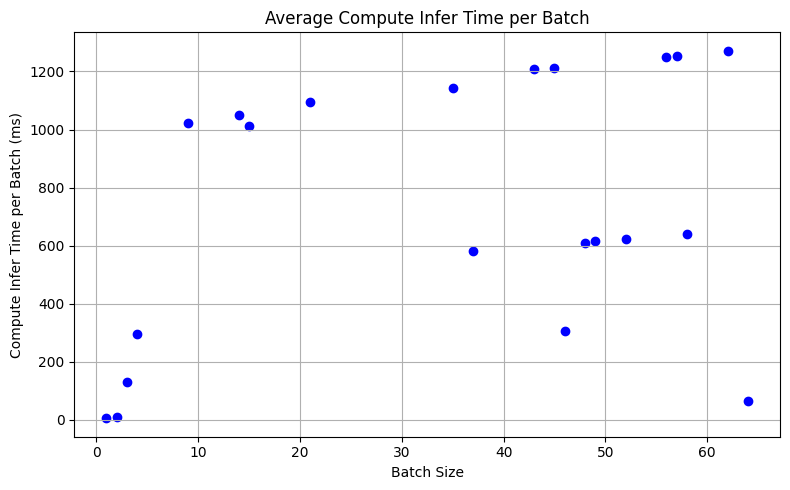

In [61]:
# Extract compute infer time per batch
batch_stats = json_input["model_stats"][0]["batch_stats"]
batch_sizes = [entry["batch_size"] for entry in batch_stats]
compute_infer_time_per_batch_ms = [
    entry["compute_infer"]["ns"] / entry["compute_infer"]["count"] / 1e6
    for entry in batch_stats
]

# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(batch_sizes, compute_infer_time_per_batch_ms, color='blue')
plt.xlabel("Batch Size")
plt.ylabel("Compute Infer Time per Batch (ms)")
plt.title("Average Compute Infer Time per Batch")
plt.grid(True)
plt.tight_layout()
plt.show()

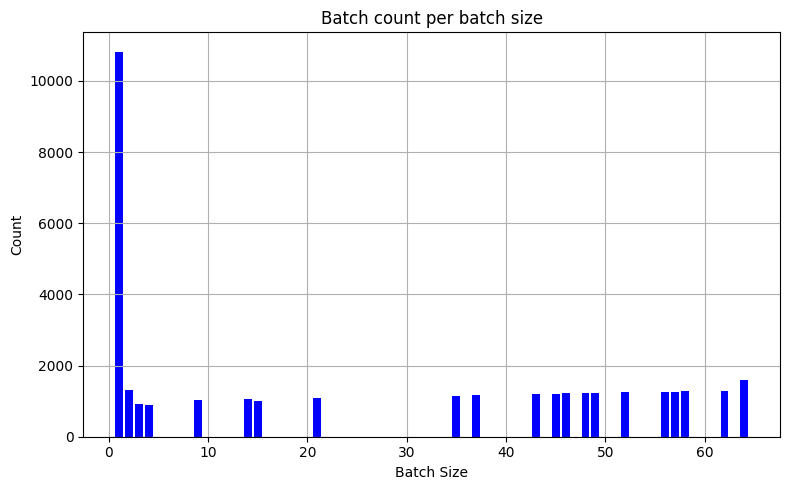

In [62]:
plt.figure(figsize=(8, 5))
compute_infer_time = [
    entry["compute_infer"]["ns"] /1e6
    for entry in batch_stats
]

plt.bar(batch_sizes, compute_infer_time, color='blue')
plt.xlabel("Batch Size")
plt.ylabel("Count")
plt.title("Batch count per batch size")
plt.grid(True)
plt.tight_layout()
plt.show()